## Bank Shield AI: Davranışsal Kredi Risk Analizi ve MVP Modelleme
Bu aşamada, işlemlerden türetilen müşteri bazlı özet verileri (customer_risk_summary) kullanarak, müşterilerin finansal ve davranışsal risk skorlarını tahmin eden bir Random Forest modeli geliştiriyoruz.

**Veri Hazırlığı ve Risk Gruplandırma**

Müşterileri riskli ve normal olarak ayırmak için is_fraud_mean (ortalama dolandırıcılık oranı) üzerinden bir eşik değer belirlenmiştir.

Eşik Değer: 0.0005 (Bu değer, modelin riskli davranış kalıplarını öğrenebilmesi için yeterli örneklem sağlamak amacıyla optimize edilmiştir).

Hedef Değişken (is_high_risk): 1 (Riskli), 0 (Normal).

💡 Teknik Not: Veri sızıntısını (Data Leakage) önlemek amacıyla, hedef değişkeni oluştururken kullandığımız is_fraud_mean ve müşteri bazlı tekil anahtar olan client_id özellik setinden (X) çıkarılmıştır.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# Veriyi processed klasöründen çekiyoruz
df_model = pd.read_parquet('../data/processed/customer_risk_summary.parquet')

# Mevcut eşiği biraz düşürerek riskli grup sayısını artıralım
# Amacımız modelin 'riskli davranış' nedir öğrenebileceği kadar örnek olması.
df_model['is_high_risk'] = (df_model['is_fraud_mean'] > 0.0005).astype(int) 

print("Yeni Dağılım:")
print(df_model['is_high_risk'].value_counts())

print("--- Yeni Risk Dağılımı ---")
print(df_model['is_high_risk'].value_counts())

# Kontrol edelim
print(df_model['is_high_risk'].value_counts())

print(f"✅ Müşteri bazlı veri yüklendi: {df_model.shape}")
print(df_model['is_high_risk'].value_counts())

Yeni Dağılım:
is_high_risk
1    842
0    377
Name: count, dtype: int64
--- Yeni Risk Dağılımı ---
is_high_risk
1    842
0    377
Name: count, dtype: int64
is_high_risk
1    842
0    377
Name: count, dtype: int64
✅ Müşteri bazlı veri yüklendi: (1219, 15)
is_high_risk
1    842
0    377
Name: count, dtype: int64


**Model Stratejisi: Random Forest**
Müşteri davranışları doğrusal (lineer) olmadığı için, karmaşık ilişkileri yakalayabilen ve hangi özelliğin neden önemli olduğunu açıklayabilen Random Forest Classifier tercih edilmiştir.

Dengeleme: Veri setindeki dengesizliği yönetmek için class_weight='balanced' kullanılmıştır.

Sentetik Veri Artırımı (SMOTE): Azınlık sınıfı desteklemek adına SMOTE uygulanarak modelin öğrenme kapasitesi artırılmıştır.

In [3]:
# 1. Özellikler (X) ve Hedefi (y) belirlenecek
# is_fraud_mean'i çıkarılacak (çünkü bu bilgiden is_high_risk'i türettik, leakage olmasın)
X = df_model.drop(columns=['client_id', 'is_fraud_mean', 'is_high_risk'])
y = df_model['is_high_risk']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 3. Model: Random Forest (Müşteri davranışlarını anlamak için en iyisidir)
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    class_weight='balanced', # Veri dengesizliği için 
    random_state=42
)

rf_model.fit(X_train, y_train)

# 4. Kaydet
joblib.dump(rf_model, '../models/mvp_behavioral_risk.joblib')
print("🚀 MVP Davranışsal Model eğitildi ve kaydedildi!")

🚀 MVP Davranışsal Model eğitildi ve kaydedildi!


In [4]:
from imblearn.over_sampling import SMOTE

# SMOTE sadece train setine uygulanır!
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"SMOTE sonrası Train Seti Dağılımı: {pd.Series(y_train_res).value_counts()}")

SMOTE sonrası Train Seti Dağılımı: is_high_risk
1    673
0    673
Name: count, dtype: int64


**En Önemli Risk Faktörleri (Feature Importance)**

Hangi davranış risk puanını daha çok etkiliyor?

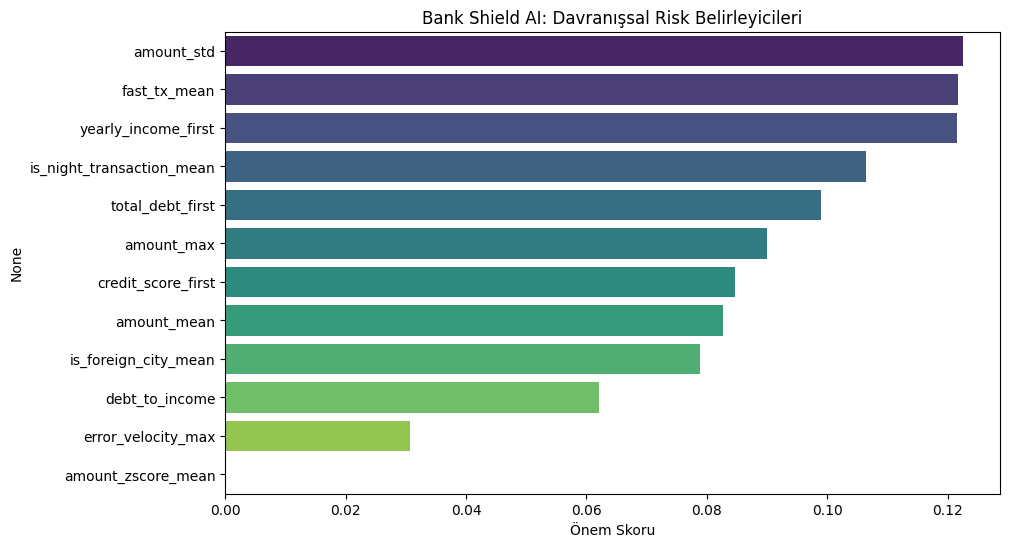

🔥 Modelin en çok dikkat ettiği 3 özellik:
amount_std             0.122531
fast_tx_mean           0.121614
yearly_income_first    0.121446
dtype: float64


In [5]:
# Modelin kararlarını neye göre verdiğini görelim
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Bank Shield AI: Davranışsal Risk Belirleyicileri')
plt.xlabel('Önem Skoru')
plt.show()

print("🔥 Modelin en çok dikkat ettiği 3 özellik:")
print(importances.head(3))

Model Performans Analizi

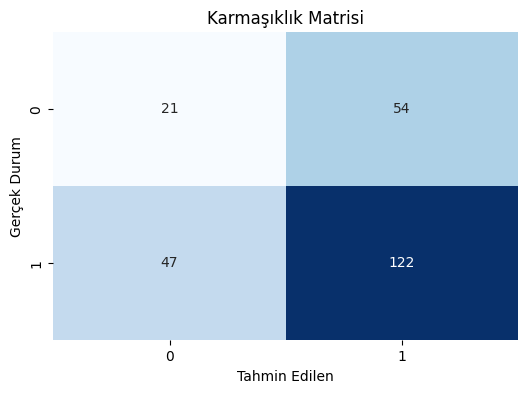


=== Model Performans Raporu ===
              precision    recall  f1-score   support

           0       0.31      0.28      0.29        75
           1       0.69      0.72      0.71       169

    accuracy                           0.59       244
   macro avg       0.50      0.50      0.50       244
weighted avg       0.58      0.59      0.58       244

ROC-AUC Skoru: 0.5540
Average Precision (PR-AUC): 0.7459


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# 1. Test seti üzerinde tahminler yapalım
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1] # Risk olasılıkları

# 2. Karmaşıklık Matrisi (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Durum')
plt.show()

# 3. Detaylı Rapor
print("\n=== Model Performans Raporu ===")
print(classification_report(y_test, y_pred))

# 4. Bankacılık İçin Kritik Metrikler
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average Precision (PR-AUC): {average_precision_score(y_test, y_proba):.4f}")

**Model Performans Değerlendirmesi**
Bankacılık sektörü için sadece doğruluk (accuracy) yeterli değildir; Precision (Kesinlik) ve Recall (Duyarlılık) dengesi kritiktir.

Confusion Matrix: Gerçek riskli durumların ne kadarının doğru tahmin edildiğini görselleştirir.

ROC-AUC: Modelin sınıfları birbirinden ayırma başarısını gösterir.

**Deployment (Streamlit Hazırlığı)**

Modelin canlı uygulamada (Streamlit) hatasız çalışması için sadece modelin kendisi değil, modelin eğitildiği özellik listesi (feature list) de bir sözlük yapısında kaydedilmiştir.

In [7]:
# mvp_model.joblib dosyasını Streamlit'e uygun hale getirelim
model_data = {
    'model': rf_model, 
    'features': X.columns.tolist()
}

# Kayıt yolunu da netleştirelim
joblib.dump(model_data, '../models/mvp_behavioral_risk.joblib')

print("🚀 Streamlit uyumlu model dosyası başarıyla güncellendi!")
print(f"Kaydedilen Kolon Sayısı: {len(X.columns.tolist())}")

🚀 Streamlit uyumlu model dosyası başarıyla güncellendi!
Kaydedilen Kolon Sayısı: 12


Bu bir MVP modelidir. ROC-AUC skorunu artırmak için daha fazla müşteri verisine ve 'Location' tabanlı (konum uyumsuzluğu) yeni özelliklere ihtiyaç duyulmaktadır.